In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score


In [127]:
df=pd.read_excel(r"C:\Users\user\OneDrive\Desktop\file.xlsx")

In [128]:
df

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,01-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,01-01-2023,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,07-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,19-01-2023,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,20-01-2023,1.0,Metric Tonnes,4550.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...
13016,Maharashtra,Thane,Fruits,Orange,01-04-2026,0.3,Metric Tonnes,6000.0,Rs./Quintal
13017,Maharashtra,Thane,Fruits,Orange,16-04-2026,0.3,Metric Tonnes,3800.0,Rs./Quintal
13018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13019,Note:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
df.head()

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,01-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,01-01-2023,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,07-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,19-01-2023,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,20-01-2023,1.0,Metric Tonnes,4550.0,Rs./Quintal


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13021 entries, 0 to 13020
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State            13020 non-null  object 
 1   District         13018 non-null  object 
 2   Commodity Group  13018 non-null  object 
 3   Commodity        13018 non-null  object 
 4   Date             13018 non-null  object 
 5   Arrival          13018 non-null  float64
 6   Arrival Unit     13018 non-null  object 
 7   Price            13018 non-null  float64
 8   Price Unit       13018 non-null  object 
dtypes: float64(2), object(7)
memory usage: 915.7+ KB


In [131]:
df.describe()

,Arrival,Price
count,13018.000000,13018.000000
mean,63.279369,6977.326519
std,191.903842,4812.755141
min,0.100000,300.000000
25%,2.600000,4000.000000
50%,13.000000,6000.000000
75%,56.700000,9000.000000
max,9330.300000,120000.000000


In [132]:
df.columns

Index(['State', 'District', 'Commodity Group', 'Commodity', 'Date', 'Arrival',
       'Arrival Unit', 'Price', 'Price Unit'],
      dtype='object')

In [133]:
df.isnull().sum()
df = df.dropna(subset=['Price'])
df.dropna()


,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,01-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,01-01-2023,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,07-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,19-01-2023,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,20-01-2023,1.0,Metric Tonnes,4550.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...
13013,Maharashtra,Thane,Fruits,Orange,06-03-2026,0.3,Metric Tonnes,4500.0,Rs./Quintal
13014,Maharashtra,Thane,Fruits,Orange,11-03-2026,0.3,Metric Tonnes,5000.0,Rs./Quintal
13015,Maharashtra,Thane,Fruits,Orange,20-03-2026,0.3,Metric Tonnes,5000.0,Rs./Quintal
13016,Maharashtra,Thane,Fruits,Orange,01-04-2026,0.3,Metric Tonnes,6000.0,Rs./Quintal


In [134]:
df.columns=df.columns.str.strip()
df = df.dropna().copy()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [135]:
df

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-01,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,2023-01-01,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-07,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-19,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-20,1.0,Metric Tonnes,4550.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...
13013,Maharashtra,Thane,Fruits,Orange,2026-03-06,0.3,Metric Tonnes,4500.0,Rs./Quintal
13014,Maharashtra,Thane,Fruits,Orange,2026-03-11,0.3,Metric Tonnes,5000.0,Rs./Quintal
13015,Maharashtra,Thane,Fruits,Orange,2026-03-20,0.3,Metric Tonnes,5000.0,Rs./Quintal
13016,Maharashtra,Thane,Fruits,Orange,2026-04-01,0.3,Metric Tonnes,6000.0,Rs./Quintal


In [136]:
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year

In [137]:
df['Commodity'] = df['Commodity'].astype('category').cat.codes

In [138]:
X=df[['Arrival','Month','Year','Commodity']]
Y=df['Price']


In [139]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [140]:
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
Y_pred=model.predict(X_test)

In [152]:
print("MAE:", mean_absolute_error(Y_test, y_pred))
print("R2 Score:", r2_score(Y_test, y_pred))

MAE: 2097.3342984404753
R2 Score: 0.4819024613010273


In [147]:
df['Predicted Price']=model.predict(X)

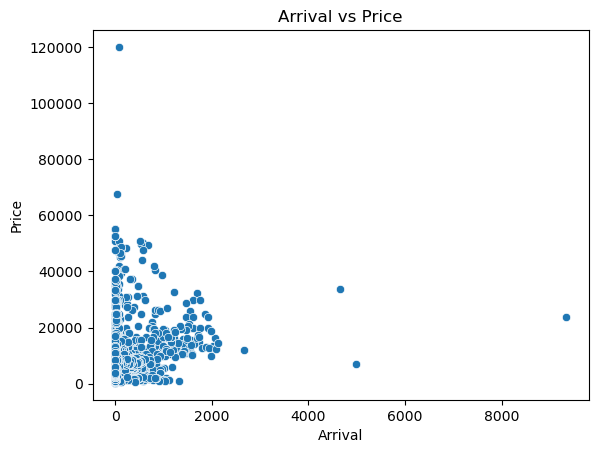

In [148]:
sns.scatterplot(x=df['Arrival'], y=df['Price'])
plt.title("Arrival vs Price")
plt.show()

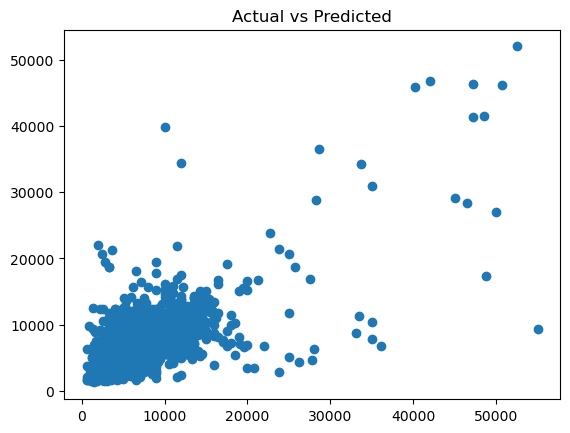

In [149]:
plt.scatter(Y_test, Y_pred)
plt.title("Actual vs Predicted")
plt.show()